# Binary classification models

## Dependencies

In [1]:
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd
import random
from collections import defaultdict
import pickle
import torch
import time
import seaborn as sns

In [2]:
from skimage import io
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import LabelEncoder
from sklearn.utils import class_weight
from sklearn.metrics import confusion_matrix, f1_score, classification_report

In [3]:
import tensorflow as tf
from tensorflow.keras.preprocessing import image
from tensorflow.keras import layers, Sequential
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import ConvLSTM2D, BatchNormalization, Conv2D
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet import preprocess_input

In [4]:
random.seed(42)
tf.random.set_seed(42)

## Data 12000 images

In [5]:
path_renders = "..\\capturas\\capturas_256x256\\ClassBin"

In [6]:
database = os.listdir(path_renders)
data_img_labels = database[0]
imgs = database[1:]
print(database[:10])
print(imgs[-1])

['dataBin.csv', 'render_0000.png', 'render_0001.png', 'render_0002.png', 'render_0003.png', 'render_0004.png', 'render_0005.png', 'render_0006.png', 'render_0007.png', 'render_0008.png']
render_9999.png


In [7]:
csv_path = os.path.join(path_renders, data_img_labels)

df = pd.read_csv(csv_path, header =0, names=["filename", "correcto"])

# Añadir ruta completa a cada imagen
df["full_path"] = df["filename"].apply(lambda x: os.path.join(path_renders, x))


print(df[["filename", "correcto"]].tail())

               filename  correcto
11994  render_11994.png     False
11995  render_11995.png     False
11996  render_11996.png      True
11997  render_11997.png      True
11998  render_11998.png      True


In [8]:
for p in imgs[:10]:    
    img_path = os.path.join(path_renders, p)
    print(img_path)

..\capturas\capturas_256x256\ClassBin\render_0000.png
..\capturas\capturas_256x256\ClassBin\render_0001.png
..\capturas\capturas_256x256\ClassBin\render_0002.png
..\capturas\capturas_256x256\ClassBin\render_0003.png
..\capturas\capturas_256x256\ClassBin\render_0004.png
..\capturas\capturas_256x256\ClassBin\render_0005.png
..\capturas\capturas_256x256\ClassBin\render_0006.png
..\capturas\capturas_256x256\ClassBin\render_0007.png
..\capturas\capturas_256x256\ClassBin\render_0008.png
..\capturas\capturas_256x256\ClassBin\render_0009.png


## Auxiliary functions

In [9]:
def show_false_labeling(idx, type, test_paths):

    num_images = len(idx)

    print(f"{type}: {num_images}")

    rows = (num_images - 1) // 5 + 1 if num_images > 0 else 1
    fig = plt.figure(figsize=(15, 3 * rows))

    print(f"=========== {type} ===========")
    for plot_idx, i in enumerate(idx):
        plt.subplot(rows, 5, plot_idx + 1)
        
        img_path = test_paths[i] 

        if not os.path.exists(img_path):
            plt.axis("off")
            plt.title(os.path.basename(img_path), color="red", fontsize=9)
            continue

        img = io.imread(img_path)

        if img.shape[-1] == 1:
            plt.imshow(img.squeeze(), cmap="gray")
        else:
            plt.imshow(img)
            
        plt.axis("off")
        
        # Mostrar sólo el nombre del archivo
        name = os.path.basename(img_path)
        plt.title(name, color="red", fontsize=9, fontweight='bold')

    plt.tight_layout()
    plt.show()

In [10]:
def get_paths_and_labels(df, test_size=0.2):
    df_valid = df[df['full_path'].apply(os.path.exists)].copy()
    
    encoder = LabelEncoder()
    df_valid['label_encoded'] = encoder.fit_transform(df_valid['correcto'])
    
    paths = df_valid['full_path'].values
    labels = df_valid['label_encoded'].values
    
    # train test (80/20)
    train_val_paths, test_paths, train_val_labels, test_labels = train_test_split(
        paths, labels, test_size=test_size, random_state=42, stratify=labels
    )

    # train val (80/20)
    train_paths, val_paths, train_labels, val_labels = train_test_split(
    train_val_paths, train_val_labels, test_size=0.2, random_state=42, stratify=train_val_labels
    )

    return (train_paths, train_labels), (val_paths, val_labels), (test_paths, test_labels), encoder


def load_image_tf(path, label, method):
    img = tf.io.read_file(path)
    img = tf.image.decode_png(img, channels=3)
    img = tf.image.resize(img, [256, 256])
    
    if method == "resnet":
        img = tf.cast(img, tf.float32) / 255.0
    elif method == "efficientnet":
        img = tf.cast(img, tf.float32) 
    elif method == "mobilenet":
        img = (tf.cast(img, tf.float32) / 127.5) - 1.0
    return img, label

In [11]:
def plot_from_history(history, epochs):
    hist = history.history if hasattr(history, 'history') else history

    # Determinar cuántas métricas tenemos para ajustar el tamaño de la figura
    has_precision_recall = 'precision' in hist and 'recall' in hist
    rows = 2 if has_precision_recall else 1
    
    plt.figure(figsize=(12, 4 * rows))
    epochs_range = range(len(hist['loss'])) # Usar el largo real de los datos

    # --- 1. Accuracy ---
    plt.subplot(rows, 2, 1)
    plt.plot(epochs_range, hist['accuracy'], label='Train Accuracy')
    plt.plot(epochs_range, hist['val_accuracy'], label='Val Accuracy')
    plt.title('Training and Validation Accuracy')
    plt.xlabel('Epochs')
    plt.legend(loc='lower right')
    plt.grid(True)


    # --- 2. Loss ---
    plt.subplot(rows, 2, 2)
    plt.plot(epochs_range, hist['loss'], label='Train Loss')
    plt.plot(epochs_range, hist['val_loss'], label='Val Loss')
    plt.title('Training and Validation Loss')
    plt.xlabel('Epochs')
    plt.legend(loc='upper right')
    plt.grid(True)

    # --- 3. Precision y Recall ---
    if has_precision_recall:
        # Precision
        plt.subplot(rows, 2, 3)
        # Nota: Keras a veces nombra la métrica 'precision_1' etc., buscamos la clave
        p_key = [k for k in hist.keys() if 'precision' in k and 'val' not in k][0]
        plt.plot(epochs_range, hist[p_key], label='Train Precision', color='green')
        plt.plot(epochs_range, hist[f'val_{p_key}'], label='Val Precision', color='lightgreen')
        plt.title('Training and Validation Precision')
        plt.xlabel('Epochs')
        plt.legend(loc='lower right')

        # Recall
        plt.subplot(rows, 2, 4)
        r_key = [k for k in hist.keys() if 'recall' in k and 'val' not in k][0]
        plt.plot(epochs_range, hist[r_key], label='Train Recall', color='purple')
        plt.plot(epochs_range, hist[f'val_{r_key}'], label='Val Recall', color='violet')
        plt.title('Training and Validation Recall')
        plt.xlabel('Epochs')
        plt.legend(loc='lower right')

    plt.tight_layout()
    plt.show()

In [12]:
def show_confusion_matrix(y_true, y_pred, class_names):

    cm = confusion_matrix(y_true, y_pred)

    tn, fp, fn, tp = cm.ravel()

    print("=== MATRIZ DE CONFUSIÓN BINARIA ===")
    print(f"{'Metrica':<20} | {'Valor':<10} | {'Interpretación'}")
    print("-" * 60)

    # Función auxiliar para imprimir filas
    def print_row(label, val, desc):
        print(f"{label:<20} | {val:<10.0f} | {desc}")

    print_row("Verdaderos Neg. (TN)", tn, f"Correctos: {class_names[0]}")
    print_row("Falsos Pos. (FP)", fp, f"Error: Era {class_names[0]} pero predijo {class_names[1]}")
    print_row("Falsos Neg. (FN)", fn, f"Error: Era {class_names[1]} pero predijo {class_names[0]}")
    print_row("Verdaderos Pos. (TP)", tp, f"Correctos: {class_names[1]}")

    print("-" * 60)

    # Resumen de estado
    total_clase_positiva = tp + fn
    umbral = total_clase_positiva * 0.25

    print(f"Estado de la clase {class_names[1]}: ", end="")
    if fn == 0 and fp == 0:
        print("Perfecto")
    elif fn > umbral:
        print(f"Muchos Falsos Negativos: {fn}")
    elif fp > umbral:
        print(f"Muchos Falsos Positivos: {fp}")
    else:
        print("OK")

    return tn, fp, fn, tp


In [13]:
def save_history(history, nombre_archivo):
    with open(nombre_archivo, "wb") as f:
        pickle.dump(history.history, f)

def load_history(nombre_archivo):
    if os.path.exists(nombre_archivo):
        with open(nombre_archivo, "rb") as f:
            loaded_history = pickle.load(f)
        print(f"Historial cargado desde {nombre_archivo}.")
        return loaded_history
    else:
        print(f"No se encontró el archivo {nombre_archivo}.")
        return None

In [14]:
def training_pipeline_db(model, train_ds, val_ds, test_ds, patience=3, epochs=10, lr=0.005):
    
    optimizer = tf.keras.optimizers.AdamW(learning_rate=lr, weight_decay=1e-4) # original value = 1e-5
    lr_callback = tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss', factor=0.5, patience=patience, verbose=1, min_lr=4e-10
    )

    early_stop = tf.keras.callbacks.EarlyStopping(
        monitor = 'val_loss',
        patience = (patience * 2),  # esperamos patience*2 para ver si reducir lr mejora
        verbose = 1,
        restore_best_weights = True # devolver mejores pesos guardados
    )

    model.compile(
        optimizer=optimizer,
        loss=tf.keras.losses.BinaryCrossentropy(from_logits=False),
        metrics=['accuracy', tf.keras.metrics.Precision(), tf.keras.metrics.Recall()]    )

    history = model.fit(
        train_ds, 
        epochs=epochs, 
        validation_data=val_ds, 
        callbacks=[lr_callback, early_stop]
    )

    print("\nEvaluando en Entrenamiento...")
    results_train = model.evaluate(train_ds, verbose=0)
    train_loss = results_train[0]
    train_acc = results_train[1]

    print("Evaluando en Test...")
    results_test = model.evaluate(test_ds, verbose=0)
    test_loss = results_test[0]
    test_acc = results_test[1]

    final_lr = float(tf.keras.backend.get_value(model.optimizer.learning_rate))
    
    return test_acc, train_acc, train_loss, test_loss, history, final_lr

## Get Dataset

In [15]:
(train_paths, train_labels), (val_paths, val_labels), (test_paths, test_labels), encoder = get_paths_and_labels(df, test_size=0.2)

print(encoder.classes_)
for i, nombre in enumerate(encoder.classes_):
    print(f"ID {i} -> Clase: {nombre}")

print(f"Total: {len(train_paths) + len(val_paths) + len(test_paths)}")
print(f"Entrenamiento: {len(train_paths)}")
print(f"Validación:    {len(val_paths)}")
print(f"Test:          {len(test_paths)}")

print("\nDistribución de clases en el dataset completo:")
print(df['correcto'].value_counts())
print(df['correcto'].value_counts(normalize=True) * 100)

[False  True]
ID 0 -> Clase: False
ID 1 -> Clase: True
Total: 11999
Entrenamiento: 7679
Validación:    1920
Test:          2400

Distribución de clases en el dataset completo:
correcto
False    6032
True     5967
Name: count, dtype: int64
correcto
False    50.270856
True     49.729144
Name: proportion, dtype: float64


C:\Users\Usuario\AppData\Local\Temp\ipykernel_26292\2423435773.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='correcto', data=df, palette='viridis')


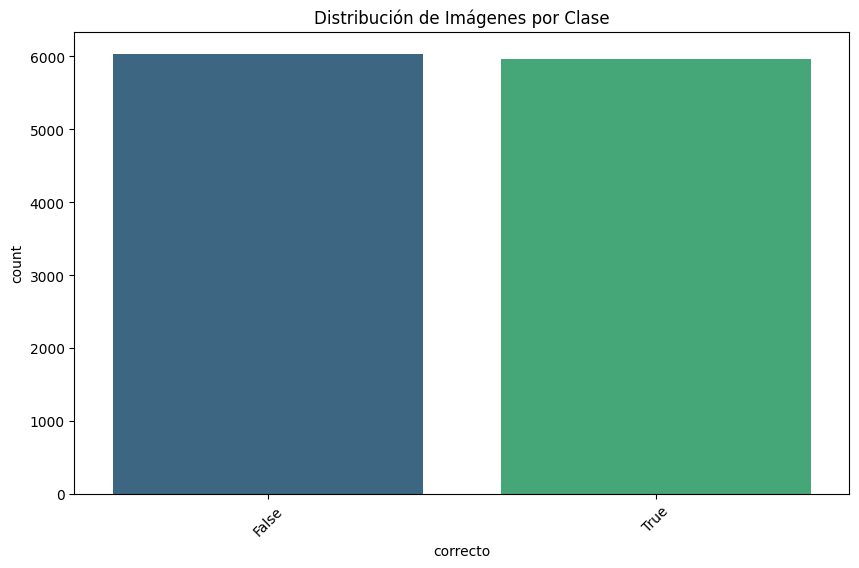

In [16]:
plt.figure(figsize=(10, 6))
sns.countplot(x='correcto', data=df, palette='viridis')
plt.title('Distribución de Imágenes por Clase')
plt.xticks(rotation=45)
plt.show()

In [17]:
# Crear dataset de entrenamiento
train_ds = tf.data.Dataset.from_tensor_slices((train_paths, train_labels))
train_ds = (train_ds
            .shuffle(len(train_paths)) # Shuffle de rutas
            .map(lambda x, y: load_image_tf(x, y, method="mobilenet"), num_parallel_calls=tf.data.AUTOTUNE) # Carga paralela
            .batch(32)
            .prefetch(tf.data.AUTOTUNE))

# Crear dataset de validación
val_ds = tf.data.Dataset.from_tensor_slices((val_paths, val_labels))
val_ds = (val_ds
          .map(lambda x, y: load_image_tf(x, y, method="mobilenet"), num_parallel_calls=tf.data.AUTOTUNE)
          .batch(32)
          .prefetch(tf.data.AUTOTUNE))

# Crear dataset de test
test_ds = tf.data.Dataset.from_tensor_slices((test_paths, test_labels))
test_ds = (test_ds
           .map(lambda x, y: load_image_tf(x, y, method="mobilenet"), num_parallel_calls=tf.data.AUTOTUNE)
           .batch(32)
           .prefetch(tf.data.AUTOTUNE))

## Models

In [17]:
resultados_tiempo = {}

### Load models


In [16]:
model_bin_mobilenet = load_model("model_bin_mobilenet.keras")
history_bin_mobilenet = load_history("history_bin_mobilenet.pkl")

Historial cargado desde history_bin_mobilenet.pkl.


### MobileNet

In [17]:
from tensorflow.keras.applications import MobileNet

#### 15 epochs

In [ ]:
start_time = time.time()

base_mobilenet = MobileNet(
    include_top = False,
    weights = None,
    input_shape = (256, 256, 3),
    pooling = "avg"
)

model_bin_mobilenet = Sequential([
    base_mobilenet,
    layers.Dropout(0.5),   # evita overfitting
    layers.Dense(1, activation='sigmoid')   # 2 clases
])

# hay más datos, añadimos más epochs
epochs = 15

test_acc_mobilenet, train_acc_mobilenet, train_loss_mobilenet, test_loss_mobilenet, history_bin_mobilenet, final_lr = training_pipeline_db(model_bin_mobilenet, train_ds, val_ds, test_ds, epochs=epochs, lr = 0.0001)
print(f"Test accuracy: {test_acc_mobilenet}\nTrain accuracy: {train_acc_mobilenet}")
print(f"Test loss: {test_loss_mobilenet}\nTrain loss: {train_loss_mobilenet}")

end_time = time.time()
training_time = end_time - start_time
resultados_tiempo['MobileNet'] = training_time
print(f"Tiempo total de entrenamiento: {training_time:.2f} segundos")
print(f"Tiempo total de entrenamiento: {training_time / 60:.2f} minutos")

Epoch 1/15
240/240 ━━━━━━━━━━━━━━━━━━━━ 870s 4s/step - accuracy: 0.5386 - loss: 0.7118 - precision: 0.5350 - recall: 0.5517 - val_accuracy: 0.4974 - val_loss: 0.6957 - val_precision: 0.4974 - val_recall: 1.0000 - learning_rate: 1.0000e-04
Epoch 2/15
240/240 ━━━━━━━━━━━━━━━━━━━━ 848s 4s/step - accuracy: 0.8247 - loss: 0.3849 - precision: 0.8012 - recall: 0.8612 - val_accuracy: 0.5026 - val_loss: 0.6933 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - learning_rate: 1.0000e-04
Epoch 3/15
240/240 ━━━━━━━━━━━━━━━━━━━━ 827s 3s/step - accuracy: 0.9423 - loss: 0.1560 - precision: 0.9218 - recall: 0.9660 - val_accuracy: 0.5026 - val_loss: 0.7043 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - learning_rate: 1.0000e-04
Epoch 4/15
240/240 ━━━━━━━━━━━━━━━━━━━━ 913s 4s/step - accuracy: 0.9646 - loss: 0.0919 - precision: 0.9558 - recall: 0.9738 - val_accuracy: 0.8635 - val_loss: 0.2877 - val_precision: 0.9664 - val_recall: 0.7518 - learning_rate: 1.0000e-04
Epoch 5/15
240/240 ━━━━━━━━━

In [41]:
model_bin_mobilenet.save("model_bin_mobilenet.keras")
save_history(history_bin_mobilenet, "history_bin_mobilenet.pkl")

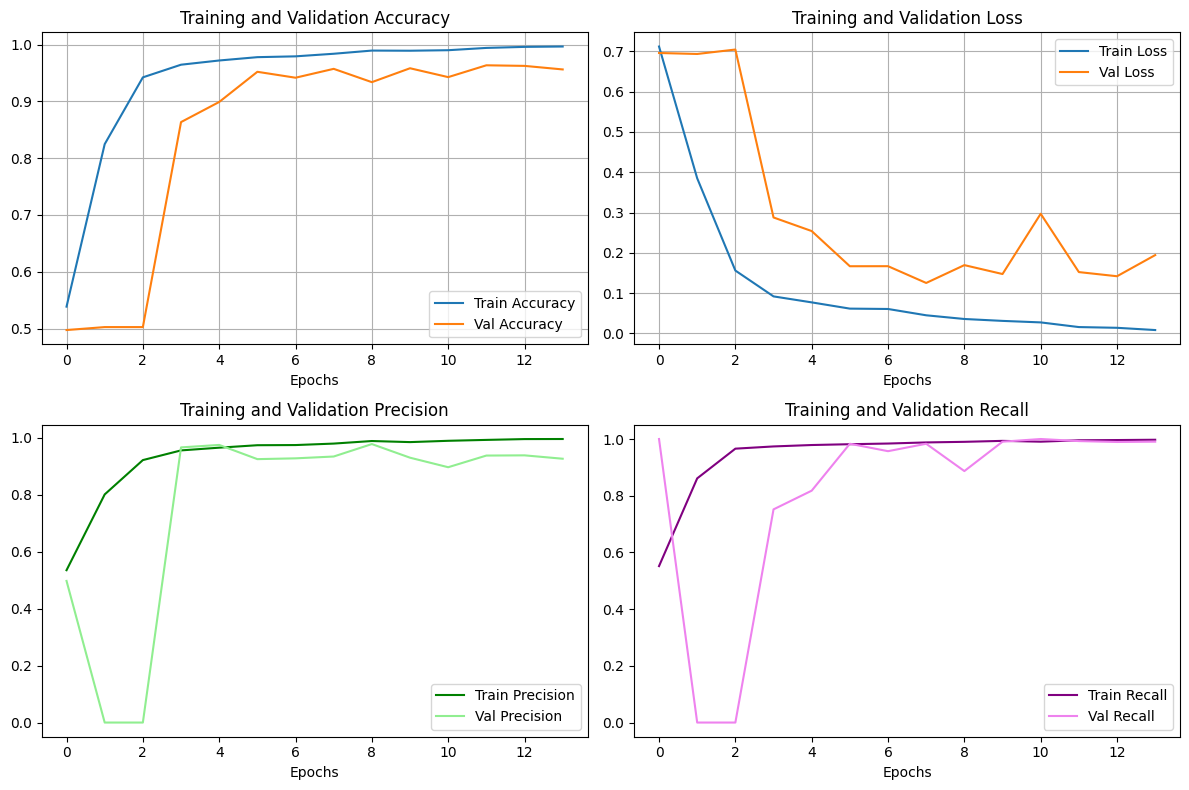

In [38]:
plot_from_history(history_bin_mobilenet, epochs = epochs)

In [19]:
y_pred_mobilenet = model_bin_mobilenet.predict(test_ds)
y_pred_classes_mobilenet = (y_pred_mobilenet > 0.5).astype(int).flatten()
class_names = encoder.classes_ 
class_names = [str(name) for name in class_names]

acc_mobilenet = accuracy_score(test_labels, y_pred_classes_mobilenet)
print(f"Accuracy MobileNet: {acc_mobilenet}")
print("-------------------------------------")

f1_mobilenet = f1_score(test_labels, y_pred_classes_mobilenet, average="weighted")
print(f"F1 Score MobileNet: {f1_mobilenet}")
print("-------------------------------------")

print("Classification Report MobileNet:")
print(classification_report(test_labels, y_pred_classes_mobilenet, target_names=class_names))

75/75 ━━━━━━━━━━━━━━━━━━━━ 42s 547ms/step
Accuracy MobileNet: 0.96625
-------------------------------------
F1 Score MobileNet: 0.9662367832521959
-------------------------------------
Classification Report MobileNet:
              precision    recall  f1-score   support

       False       0.99      0.94      0.97      1207
        True       0.95      0.99      0.97      1193

    accuracy                           0.97      2400
   macro avg       0.97      0.97      0.97      2400
weighted avg       0.97      0.97      0.97      2400



In [20]:
tn, fp, fn, tp =show_confusion_matrix(test_labels, y_pred_classes_mobilenet, class_names)

=== MATRIZ DE CONFUSIÓN BINARIA ===
Metrica              | Valor      | Interpretación
------------------------------------------------------------
Verdaderos Neg. (TN) | 1139       | Correctos: False
Falsos Pos. (FP)     | 68         | Error: Era False pero predijo True
Falsos Neg. (FN)     | 13         | Error: Era True pero predijo False
Verdaderos Pos. (TP) | 1180       | Correctos: True
------------------------------------------------------------
Estado de la clase True: OK


In [21]:
index_fn = np.where((test_labels == 1) & (y_pred_classes_mobilenet == 0))[0]
index_fp = np.where((test_labels == 0) & (y_pred_classes_mobilenet == 1))[0] 

FALSOS POSITIVOS: 68
=========== FALSOS POSITIVOS ===========


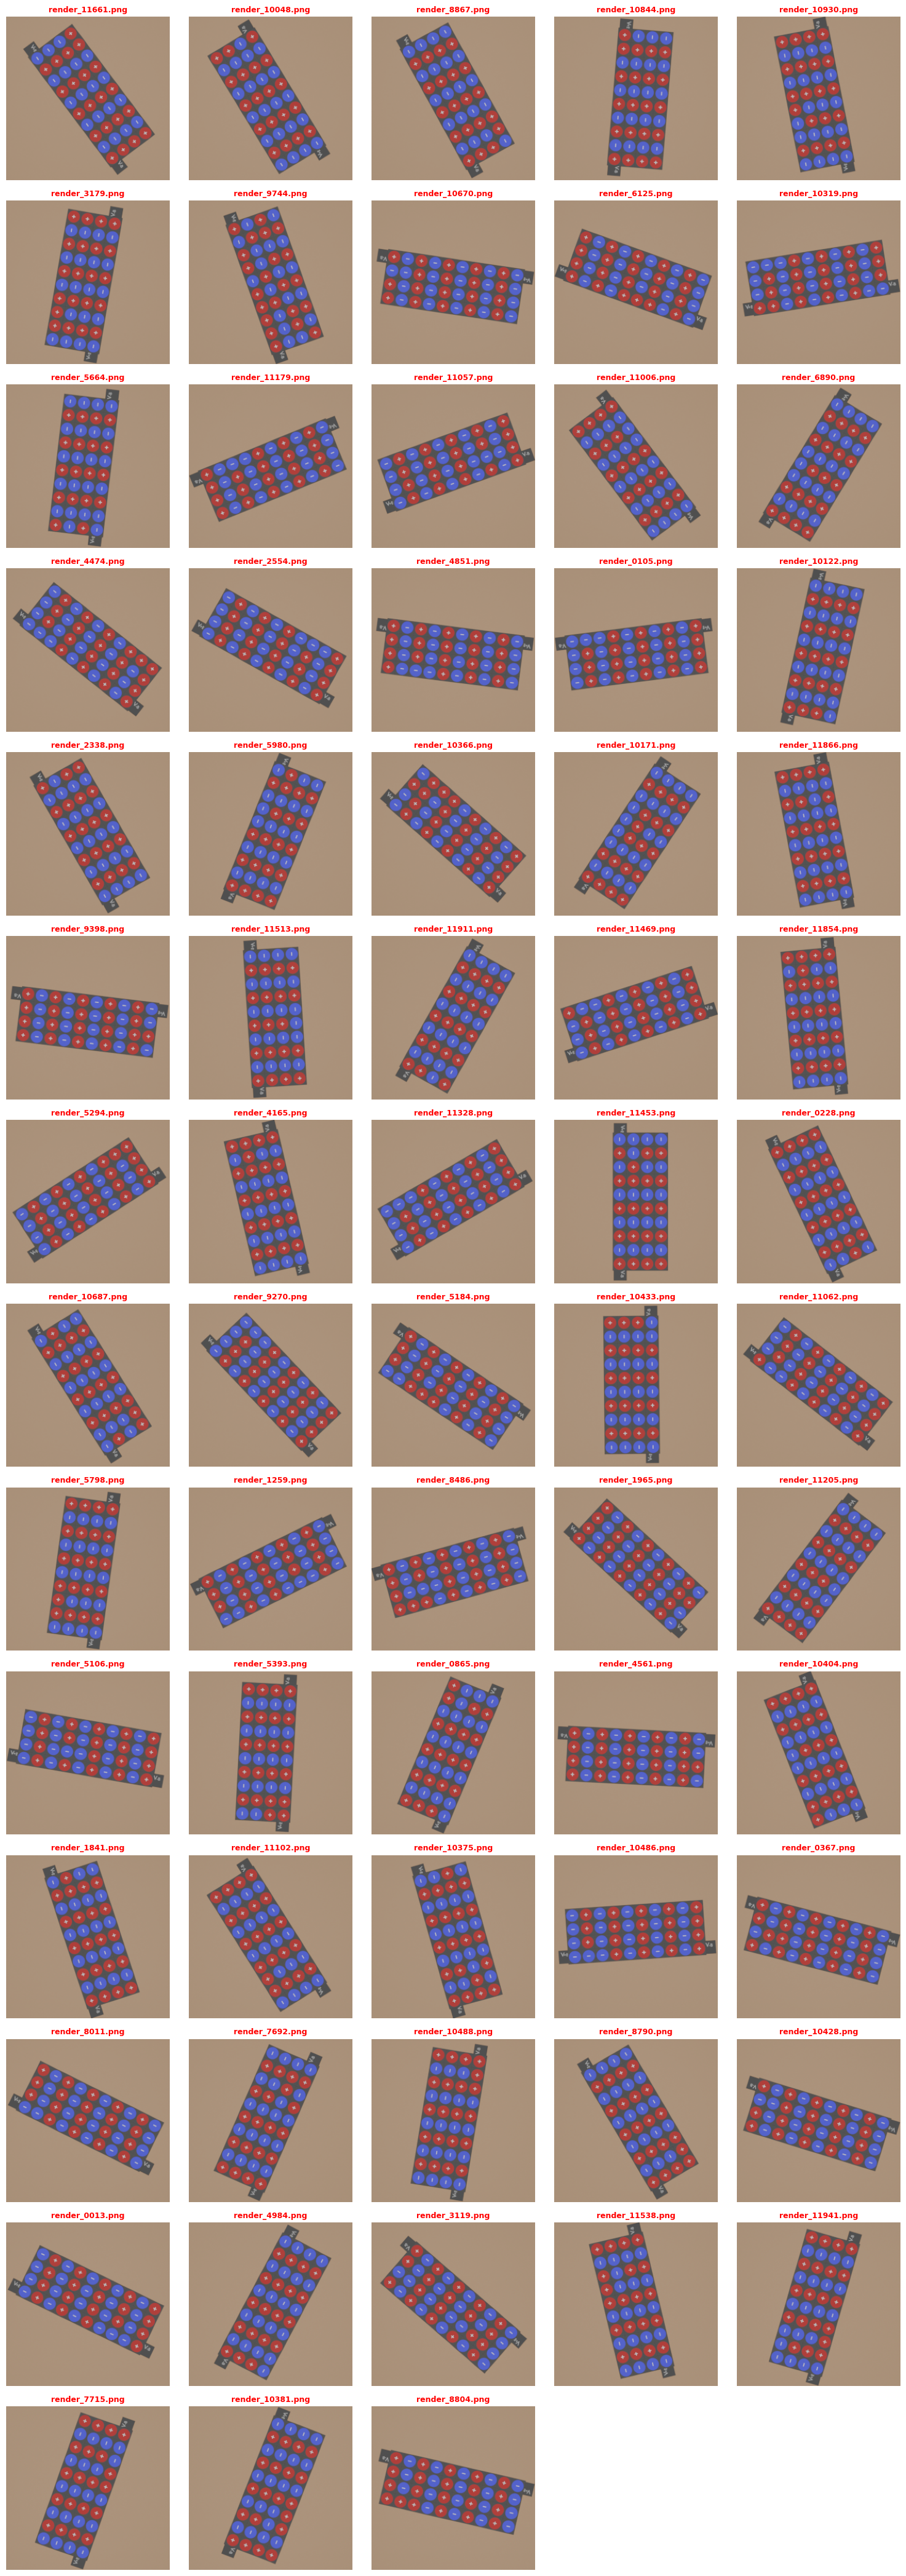

In [22]:
show_false_labeling(index_fp, "FALSOS POSITIVOS", test_paths)

Muchos de los FP tienen pocas pilas mal $\rightarrow$ crear más imágenes que tengan de 1 a 5 pilas mal colocadas

### Comparación



##### Entrenamiento de 10 epochs seguidas 12000 imágenes

Train, test y val con datos capturados desde Blender

| Métrica                | Valor | Interpretación                              |
|------------------------|------:|---------------------------------------------|
| Verdaderos Neg. (TN)   |  1030 | Correctos: False                            |
| Falsos Pos. (FP)       |   177 | Error: Era False pero predijo True          |
| Falsos Neg. (FN)       |   104 | Error: Era True pero predijo False          |
| Verdaderos Pos. (TP)   |  1089 | Correctos: True                             |
   
val_loss de 0.4 -> añadimos más epochs

##### Entrenamiento con 15 epochs seguidas 12000 imágenes
lr=0.0001 + dropout 0.5 + Adam

| Métrica                | Valor | Interpretación                              |
|------------------------|------:|---------------------------------------------|
| Verdaderos Neg. (TN)   |  1112 | Correctos: False                            |
| Falsos Pos. (FP)       |    95 | Error: Era False pero predijo True          |
| Falsos Neg. (FN)       |   136 | Error: Era True pero predijo False          |
| Verdaderos Pos. (TP)   |  1057 | Correctos: True                             |

val_loss sigue siendo alto pero:  

- Accuracy MobileNet: 0.90375
- F1 Score MobileNet: 0.9037122989938291

| Clase   | Precision | Recall | F1-score | Support |
|---------|----------:|-------:|---------:|--------:|
| False   |      0.89 |   0.92 |     0.91 |    1207 |
| True    |      0.92 |   0.89 |     0.90 |    1193 |
| Accuracy|           |        |     0.90 |    2400 |
| Macro avg |     0.90 |   0.90 |     0.90 |    2400 |
| Weighted avg |  0.90 |   0.90 |     0.90 |    2400 |


##### 15 epochs + lr=0.0001 + dropout 0.5 + AdamW

| Métrica                | Valor | Interpretación                              |
|------------------------|------:|---------------------------------------------|
| Verdaderos Neg. (TN)   |  1139 | Correctos: False                            |
| Falsos Pos. (FP)       |    68 | Error: Era False pero predijo True          |
| Falsos Neg. (FN)       |    13 | Error: Era True pero predijo False          |
| Verdaderos Pos. (TP)   |  1180 | Correctos: True                             |

#### MobileNetV2

##### 15 epochs + lr=0.0001 + dropout 0.5 + AdamW + patience = 5 + imagenet weights
sin los pesos de imagenet el acc es de ~0.54

| Métrica                | Valor | Interpretación                              |
|------------------------|------:|---------------------------------------------|
| Verdaderos Neg. (TN)   |  1206 | Correctos: False                            |
| Falsos Pos. (FP)       |     1 | Error: Era False pero predijo True          |
| Falsos Neg. (FN)       |     0 | Error: Era True pero predijo False          |
| Verdaderos Pos. (TP)   |  1193 | Correctos: True                             |

### MobileNetV2

In [18]:
from tensorflow.keras.applications import MobileNetV2

In [19]:
start_time = time.time()

base_mobilenetV2 = MobileNetV2(
    include_top = False,
    weights = "imagenet",
    input_shape = (256, 256, 3),
    pooling = "avg"
)

model_bin_mobilenetV2 = Sequential([
    base_mobilenetV2,
    layers.Dropout(0.5),  
    layers.Dense(1, activation='sigmoid')   # 2 clases
])

epochs = 15 # cambiar patience

test_acc_mobilenetV2, train_acc_mobilenetV2, train_loss_mobilenetV2, test_loss_mobilenetV2, history_bin_mobilenetV2, final_lr = training_pipeline_db(model_bin_mobilenetV2, train_ds, val_ds, test_ds, patience = 5, epochs=epochs, lr = 0.0001)
print(f"Test accuracy: {test_acc_mobilenetV2}\nTrain accuracy: {train_acc_mobilenetV2}")
print(f"Test loss: {test_loss_mobilenetV2}\nTrain loss: {train_loss_mobilenetV2}")

end_time = time.time()
training_time = end_time - start_time
print(f"Tiempo total de entrenamiento: {training_time:.2f} segundos")
print(f"Tiempo total de entrenamiento: {training_time / 60:.2f} minutos")

C:\Users\Usuario\AppData\Local\Temp\ipykernel_26292\3230922316.py:3: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_mobilenetV2 = MobileNetV2(


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Epoch 1/15
240/240 ━━━━━━━━━━━━━━━━━━━━ 1131s 5s/step - accuracy: 0.9137 - loss: 0.2099 - precision: 0.9007 - recall: 0.9288 - val_accuracy: 0.5276 - val_loss: 0.7101 - val_precision: 0.7353 - val_recall: 0.0785 - learning_rate: 1.0000e-04
Epoch 2/15
240/240 ━━━━━━━━━━━━━━━━━━━━ 1333s 6s/step - accuracy: 0.9888 - loss: 0.0363 - precision: 0.9829 - recall: 0.9948 - val_accuracy: 0.6047 - val_loss: 0.5383 - val_precision: 0.9414 - val_recall: 0.2188 - learning_rate: 1.0000e-04
Epoch 3/15
240/240 ━━━━━━━━━━━━━━━━━━━━ 1264s 5s/step - accuracy: 0.9984 - loss: 0.0061 - precision: 0.9974 - recall: 0.9995 - val_accuracy: 0.8797 - val_loss: 0.3019 - val_precision: 0.9361 - val_recall: 0.8136 - learning_rate: 1.0000e-04
Epoch 4/15
240/240 ━━━━━━━━━━━━━━━━━━━━ 1108s 5s/step - accuracy: 0.9987 - loss: 0.0046 - precision: 0.9982 - recall: 0.9992 - val_accuracy: 0.9661 - val_loss: 0.1546 - val_precision: 0.9406 - val_recall: 0.9948 - learning_rate: 1.

In [20]:
model_bin_mobilenetV2.save("model_bin_mobilenetV2.keras")
save_history(history_bin_mobilenetV2, "history_bin_mobilenetV2.pkl")

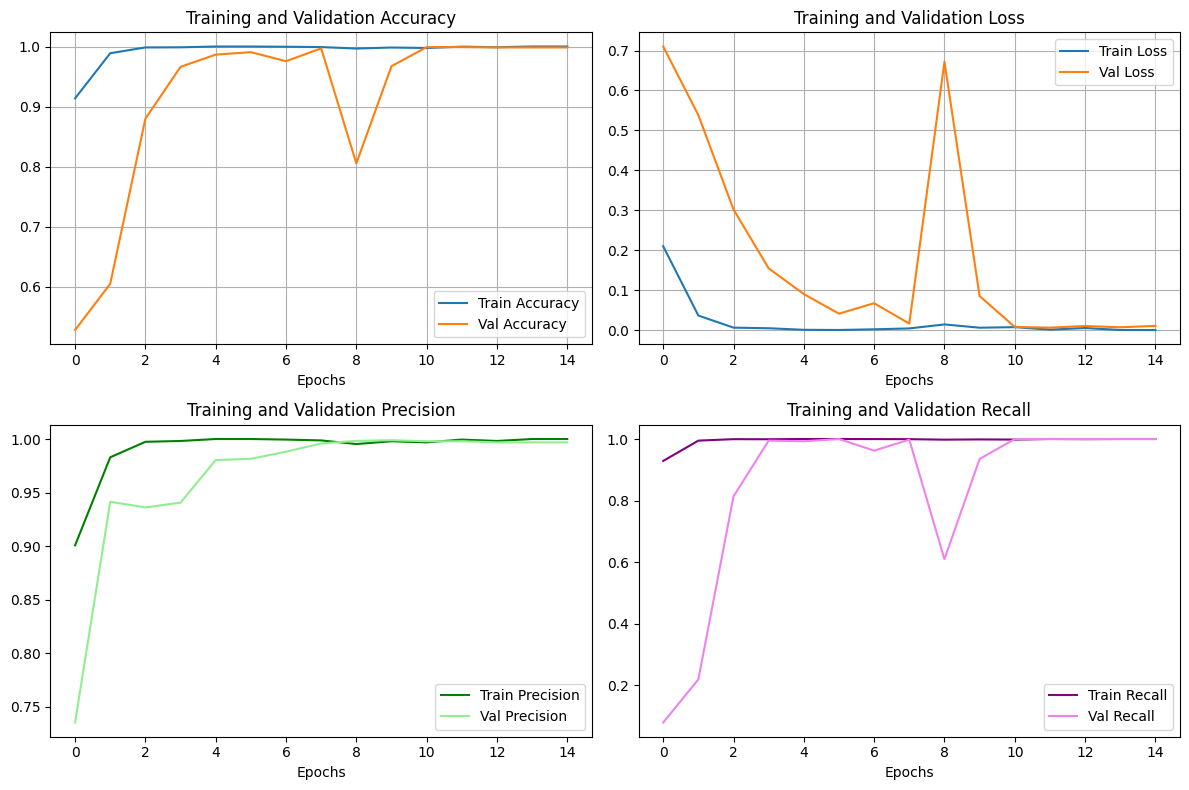

In [21]:
plot_from_history(history_bin_mobilenetV2, epochs = epochs)

In [22]:
y_pred_mobilenetV2 = model_bin_mobilenetV2.predict(test_ds)
y_pred_classes_mobilenetV2 = (y_pred_mobilenetV2 > 0.5).astype(int).flatten()
class_names = encoder.classes_ 
class_names = [str(name) for name in class_names]

acc_mobilenetV2 = accuracy_score(test_labels, y_pred_classes_mobilenetV2)
print(f"Accuracy MobileNetV2: {acc_mobilenetV2}")
print("-------------------------------------")

f1_mobilenetV2 = f1_score(test_labels, y_pred_classes_mobilenetV2, average="weighted")
print(f"F1 Score MobileNetV2: {f1_mobilenetV2}")
print("-------------------------------------")

print("Classification Report MobileNetV2:")
print(classification_report(test_labels, y_pred_classes_mobilenetV2, target_names=class_names))

75/75 ━━━━━━━━━━━━━━━━━━━━ 58s 712ms/step
Accuracy MobileNetV2: 0.9995833333333334
-------------------------------------
F1 Score MobileNetV2: 0.9995833342737545
-------------------------------------
Classification Report MobileNetV2:
              precision    recall  f1-score   support

       False       1.00      1.00      1.00      1207
        True       1.00      1.00      1.00      1193

    accuracy                           1.00      2400
   macro avg       1.00      1.00      1.00      2400
weighted avg       1.00      1.00      1.00      2400



In [23]:
tn, fp, fn, tp =show_confusion_matrix(test_labels, y_pred_classes_mobilenetV2, class_names)

=== MATRIZ DE CONFUSIÓN BINARIA ===
Metrica              | Valor      | Interpretación
------------------------------------------------------------
Verdaderos Neg. (TN) | 1206       | Correctos: False
Falsos Pos. (FP)     | 1          | Error: Era False pero predijo True
Falsos Neg. (FN)     | 0          | Error: Era True pero predijo False
Verdaderos Pos. (TP) | 1193       | Correctos: True
------------------------------------------------------------
Estado de la clase True: OK


In [24]:
index_fn = np.where((test_labels == 1) & (y_pred_classes_mobilenetV2 == 0))[0]
index_fp = np.where((test_labels == 0) & (y_pred_classes_mobilenetV2 == 1))[0] 

FALSOS POSITIVOS: 1
=========== FALSOS POSITIVOS ===========


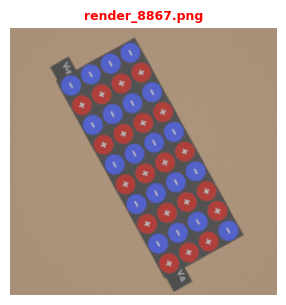

In [25]:
show_false_labeling(index_fp, "FALSOS POSITIVOS", test_paths)

# ---------------------------

In [23]:
def get_real_test_dataset():
    path =  "../capturas/capturas_256x256/capturasVR"
    database = os.listdir(path)
    data_img_labels = database[0]

    csv_path = os.path.join(path, data_img_labels)

    df = pd.read_csv(csv_path, header =0, names=["filename", "label"])

    df["full_path"] = df["filename"].apply(lambda x: os.path.join(path, x))
    df_valid = df[df['full_path'].apply(os.path.exists)].copy()
    
    encoder = LabelEncoder()
    df_valid['label_encoded'] = encoder.fit_transform(df_valid['label'])
    
    df_class_2 = df_valid[df_valid['label_encoded'] == 2].copy()
    df_class_2['label_binary'] = True   
    
    paths = df_class_2['full_path'].values
    labels = df_class_2['label_binary'].values

    return tf.data.Dataset.from_tensor_slices((paths, labels))

In [24]:
real_test_ds = get_real_test_dataset()
real_test_ds = (real_test_ds
           .map(lambda x, y: load_image_tf(x, y, method="mobilenet"), num_parallel_calls=tf.data.AUTOTUNE)
           .batch(32)
           .prefetch(tf.data.AUTOTUNE))

y_true_list = []
for images, labels in real_test_ds:
    y_true_list.append(labels.numpy())

y_true_real = np.concatenate(y_true_list, axis=0)

y_pred_real = model_bin_mobilenet.predict(real_test_ds)
y_pred_classes_real= (y_pred_real > 0.5).astype(int).flatten()

class_names_real = encoder.classes_ 
class_names_real = [str(name) for name in class_names_real]

acc_mobilenet = accuracy_score(y_true_real, y_pred_classes_real)
print(f"Accuracy MobileNet: {acc_mobilenet}")
print("-------------------------------------")

f1_mobilenet = f1_score(y_true_real, y_pred_classes_real, average="weighted")
print(f"F1 Score MobileNet: {f1_mobilenet}")
print("-------------------------------------")

print("Classification Report MobileNet:")
print(classification_report(y_true_real, y_pred_classes_real, target_names=class_names_real))


8/8 ━━━━━━━━━━━━━━━━━━━━ 6s 619ms/step
Accuracy MobileNet: 0.0
-------------------------------------
F1 Score MobileNet: 0.0
-------------------------------------
Classification Report MobileNet:
              precision    recall  f1-score   support

       False       0.00      0.00      0.00       0.0
        True       0.00      0.00      0.00     239.0

    accuracy                           0.00     239.0
   macro avg       0.00      0.00      0.00     239.0
weighted avg       0.00      0.00      0.00     239.0



c:\Users\Usuario\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Usuario\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Usuario\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(avera

In [25]:
show_confusion_matrix(y_true_real, y_pred_classes_real, class_names_real)

=== MATRIZ DE CONFUSIÓN BINARIA ===
Metrica              | Valor      | Interpretación
------------------------------------------------------------
Verdaderos Neg. (TN) | 0          | Correctos: False
Falsos Pos. (FP)     | 0          | Error: Era False pero predijo True
Falsos Neg. (FN)     | 239        | Error: Era True pero predijo False
Verdaderos Pos. (TP) | 0          | Correctos: True
------------------------------------------------------------
Estado de la clase True: Muchos Falsos Negativos: 239


(np.int64(0), np.int64(0), np.int64(239), np.int64(0))